In [24]:
#cargamos las siguientes librerias 


import sklearn as sk
from sklearn.preprocessing import LabelEncoder #importamos esta funcion de sklearn
from sklearn.model_selection import train_test_split #esta linea es necesaria para Navie Bayes
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from ucimlrepo import fetch_ucirepo #esta linea es necesaria para utilizar la base de datos 


In [6]:
#importamos ahora la base de datos 
!pip install ucimlrepo

In [12]:
# fetch dataset 
car_evaluation = fetch_ucirepo(id=19) 
  
# data (as pandas dataframes) 
X = car_evaluation.data.features 
y = car_evaluation.data.targets 
  
# metadata 
print(car_evaluation.metadata) 
  
# variable information 
print(car_evaluation.variables) 

{'uci_id': 19, 'name': 'Car Evaluation', 'repository_url': 'https://archive.ics.uci.edu/dataset/19/car+evaluation', 'data_url': 'https://archive.ics.uci.edu/static/public/19/data.csv', 'abstract': 'Derived from simple hierarchical decision model, this database may be useful for testing constructive induction and structure discovery methods.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1728, 'num_features': 6, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1988, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5JP48', 'creators': ['Marko Bohanec'], 'intro_paper': {'ID': 249, 'type': 'NATIVE', 'title': 'Knowledge acquisition and explanation for multi-attribute decision making', 'authors': 'M. Bohanec, V. Rajkovič', 'venue': '8th Intl Workshop on Expert Systems and their Applications, 

In [20]:
#Ahora vamos a realizar una coṕia de data frame 
X = car_evaluation.data.features.copy()
y = car_evaluation.data.targets.copy()
#Navie Bayes funciona con datos numeros, de modo que vamos a convertitr las variables categoricas en numericas 
le_dict = {}
for column in X.columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    le_dict[column] = le

In [38]:
# Convertimos también la variable objetivo
le_target = LabelEncoder()
y = le_target.fit_transform(y.ravel())

# Paso 3: dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Paso 4: aplicar Naive Bayes (CategoricalNB para datos categóricos)
#agreganos la siguiente funcion de sklearning
from sklearn.naive_bayes import CategoricalNB
model = CategoricalNB()
model.fit(X_train, y_train)

# Paso 5: evaluar el modelo
#agregamos la siguiente funcion de sklearnig
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_test)
target_names = ['unacc', 'acc', 'good', 'vgood']  # etiquetas reales del dataset

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=target_names))


Accuracy: 0.815028901734104

Classification report:
               precision    recall  f1-score   support

       unacc       0.63      0.54      0.58        83
         acc       0.57      0.36      0.44        11
        good       0.87      0.97      0.91       235
       vgood       1.00      0.35      0.52        17

    accuracy                           0.82       346
   macro avg       0.77      0.56      0.62       346
weighted avg       0.81      0.82      0.80       346



In [40]:
#para el algoritmo SVM importamos 
from sklearn.svm import SVC

In [48]:
#creamos el modelo SVC 
model_svm = SVC()  
model_svm.fit(X_train, y_train)
y_pred = model_svm.predict(X_test)
target_names = ['unacc', 'acc', 'good', 'vgood']

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.9132947976878613

Classification report:
               precision    recall  f1-score   support

       unacc       0.88      0.76      0.81        83
         acc       1.00      0.45      0.62        11
        good       0.92      0.99      0.95       235
       vgood       0.94      0.88      0.91        17

    accuracy                           0.91       346
   macro avg       0.93      0.77      0.83       346
weighted avg       0.91      0.91      0.91       346



In [50]:
#para comparar los  modelos primero los entrnamos 
from sklearn.naive_bayes import CategoricalNB
from sklearn.svm import SVC

# Modelo Naive Bayes
nb_model = CategoricalNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

# Modelo SVM
svm_model = SVC()  # puedes usar kernel='linear', 'rbf', etc.
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)


In [52]:
#evaluamos ahora los modelos 
from sklearn.metrics import accuracy_score, classification_report

target_names = ['unacc', 'acc', 'good', 'vgood']  # ajusta si es necesario

# Evaluar Naive Bayes
print("----- Naive Bayes -----")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print("Classification Report:\n", classification_report(y_test, nb_pred, target_names=target_names))

# Evaluar SVM
print("\n----- SVM -----")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Classification Report:\n", classification_report(y_test, svm_pred, target_names=target_names))


----- Naive Bayes -----
Accuracy: 0.815028901734104
Classification Report:
               precision    recall  f1-score   support

       unacc       0.63      0.54      0.58        83
         acc       0.57      0.36      0.44        11
        good       0.87      0.97      0.91       235
       vgood       1.00      0.35      0.52        17

    accuracy                           0.82       346
   macro avg       0.77      0.56      0.62       346
weighted avg       0.81      0.82      0.80       346


----- SVM -----
Accuracy: 0.9132947976878613
Classification Report:
               precision    recall  f1-score   support

       unacc       0.88      0.76      0.81        83
         acc       1.00      0.45      0.62        11
        good       0.92      0.99      0.95       235
       vgood       0.94      0.88      0.91        17

    accuracy                           0.91       346
   macro avg       0.93      0.77      0.83       346
weighted avg       0.91      0.91      

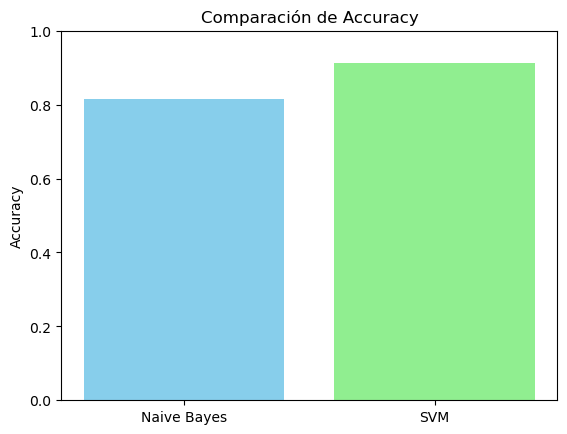

In [54]:
#comparamos ahora graficamente 
import matplotlib.pyplot as plt

accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, svm_pred)
]

labels = ['Naive Bayes', 'SVM']

plt.bar(labels, accuracies, color=['skyblue', 'lightgreen'])
plt.title('Comparación de Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()